### 第2章 Matplotlib 进阶
#### 1. 日期数据
- `Matplotlib` 中的 `dates` 模块用浮点数表示日期和时间
    - 基准点为公元元年1月1日，UTC时间00:00，无法表示公元1年之前的日期
    - 天数表示从基准点开始计算的天数 +1
    - 时间通过小数部分表示

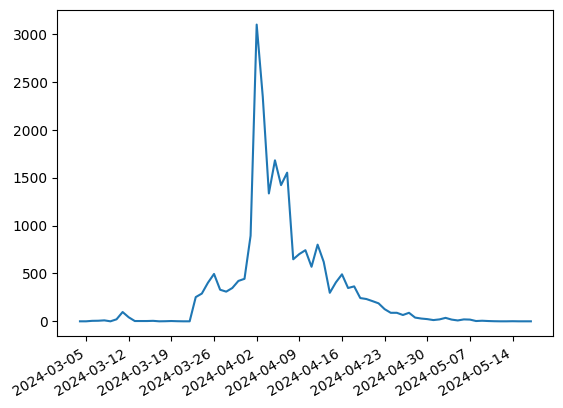

In [ ]:
import pandas as pd  # 导入pandas模块
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块
import matplotlib.dates as mdates  # 导入matplotlib.dates模块

# 读取Excel文件
df = pd.read_excel("../datas/data1.xlsx")
# xy轴数据
x = df["日期"]
y = df["数据1"]
# 设置x坐标轴日期刻度的位置
# 日期显示格式为年月
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m-%d"))
plt.gca().xaxis.set_major_locator(mdates.WeekdayLocator())  # 设置x坐标轴日期刻度的位置为每周的周一
plt.gcf().autofmt_xdate()  # 自动旋转日期标记
plt.plot(x, y)  # 绘制图表
plt.show()  # 显示图表

#### 2. 共享坐标轴
- `plt.twinx(ax=None)` 用于创建双y轴图表，返回一个共享x轴、两个y轴，第二个y轴显示在子图表的右侧
- `plt.twiny(ax=None)` 用于创建双x轴图表，返回一个共享y轴、两个x轴，第二个x轴显示在子图表的顶部
    - `ax`：可选，指定要共享的轴。如果不提供，则默认为当前激活的轴

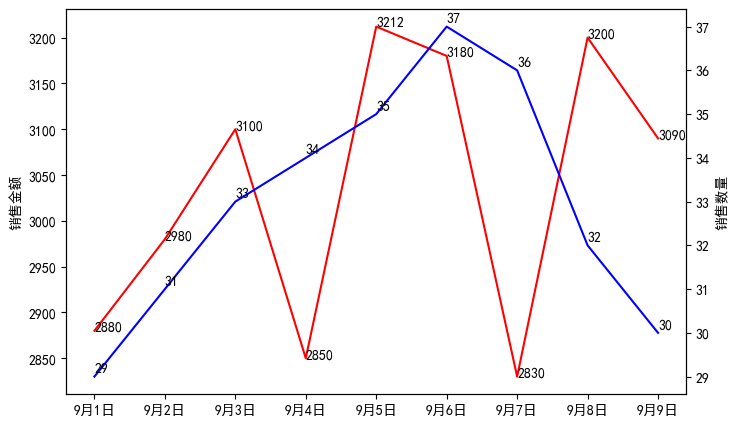

In [17]:
import pandas as pd  # 导入pandas模块
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块

# 创建数据
df = pd.DataFrame(
    {
        "日期": [
            "9月1日",
            "9月2日",
            "9月3日",
            "9月4日",
            "9月5日",
            "9月6日",
            "9月7日",
            "9月8日",
            "9月9日",
        ],
        "销售数量": [29, 31, 33, 34, 35, 37, 36, 32, 30],
        "销售金额": [2880, 2980, 3100, 2850, 3212, 3180, 2830, 3200, 3090],
    }
)
# 设置x轴和两个y轴的数据
x = df["日期"]
y1 = df["销售金额"]
y2 = df["销售数量"]
# 解决中文乱码
plt.rcParams["font.sans-serif"] = ["SimHei"]
# 设置画布大小
fig = plt.figure(figsize=(8, 5))
# 创建子图表
ax1 = fig.add_subplot(111)
# 第一个折线图
ax1.plot(x, y1, color="red")
# 第一个y轴标签
ax1.set_ylabel("销售金额")

# 第二个折线图
ax2 = ax1.twinx()  # 共享x轴，创建双 y 轴图表
ax2.plot(x, y2, color="blue")
# 第二个y轴标签
ax2.set_ylabel("销售数量")
# 销售金额文本标签
for a, b in zip(x, y1):
    ax1.text(a, b+0.1, b)
# 销售数量文本标签
for a, b in zip(x, y2):
    ax2.text(a, b+0.1, b)
plt.show()  # 显示图表

#### 3. 绘制多个子图表
- `subplot()` 函数可以用于划分画布并指定子图表的绘图位置，包括行数、列数和绘图位置。前面两个参数指定分割的行数和列数，第三个参数用来指定当前绘图位置的索引，编号规则是行优先
- `subplots(nrows, ncols, sharex, sharey, squeeze, subplot_kw, gredspec_kw, **fig_kw)` 函数用于创建画布和子图表
    - `nrows` 和 `ncols` 分别指定行数和列数，起始值都为0
    - `sharex` 和 `sharey` 分别指定是否共享x轴和y轴的属性，默认为False，或者为none, all, row, col
    - `squeeze` 默认为True，对 $n \times m (n>1, m>1)$ 个子图表，返回二维数组，否则返回一维数组；如果值为False，则总是返回二维数组
    - `subplot_kw` 字典关键字传给 add_subplot() 方法来创建每个子图表
    - `gridspec_kw` 典关键字传给 GridSpec() 构造函数来创建子图表并放在网格里
    - `**fig_kw` 把所有详细的关键字传给 figure
- `add_subplot()` 函数绘制多个图表，用法与 `subplot()` 基本相同

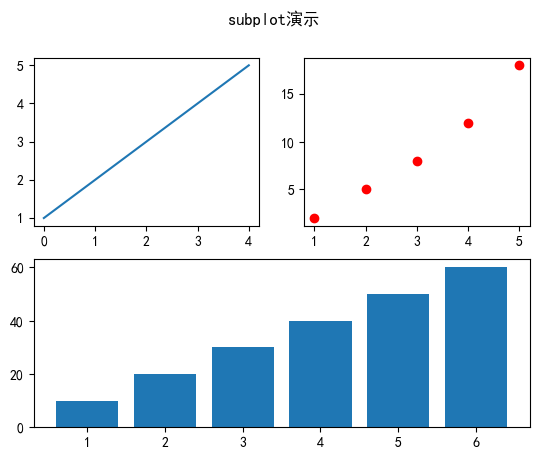

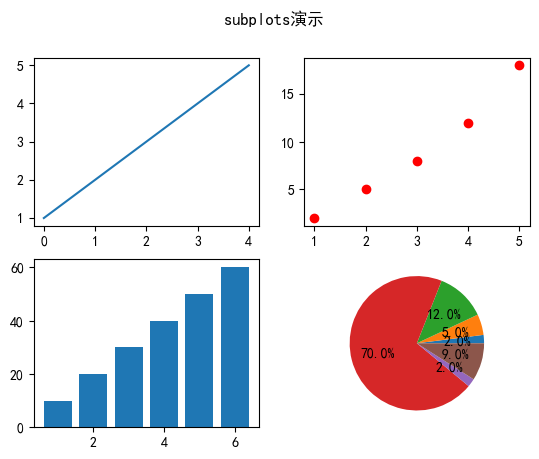

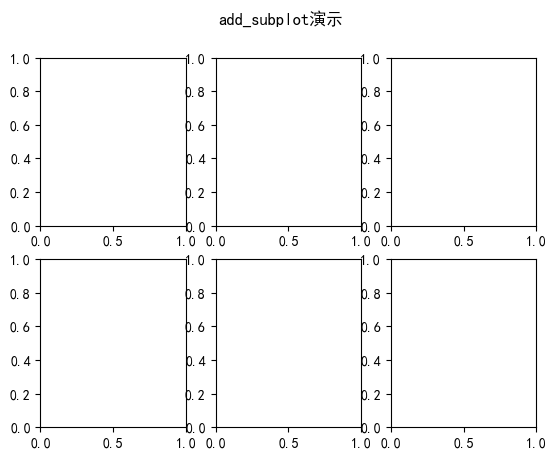

In [29]:
import matplotlib.pyplot as plt  
plt.rcParams["font.sans-serif"] = ["SimHei"]

# ----- subplot 函数 -----------
plt.subplot(2, 2, 1)    # 第1个子图表-折线图
plt.plot([1, 2, 3, 4, 5])
plt.subplot(2, 2, 2)    # 第2个子图表-散点图
plt.plot([1, 2, 3, 4, 5], [2, 5, 8, 12, 18], "ro")
plt.subplot(2, 1, 2)  # 第3个子图表-柱形图
x = [1, 2, 3, 4, 5, 6]
height = [10, 20, 30, 40, 50, 60]
plt.bar(x, height)
plt.suptitle("subplot演示")
# plt.show()  # 显示图表

# ----- subplots 函数 -----------
figure, axes = plt.subplots(2, 2)  # 2行2列的子图
axes[0, 0].plot([1, 2, 3, 4, 5])  # 第1个子图表-折线图
axes[0, 1].plot([1, 2, 3, 4, 5], [2, 5, 8, 12, 18], "ro")  # 第2个子图表-散点图
# 第3个子图表-柱形图
x = [1, 2, 3, 4, 5, 6]
height = [10, 20, 30, 40, 50, 60]
axes[1, 0].bar(x, height)
# 第4个子图表-饼形图
x = [2, 5, 12, 70, 2, 9]
axes[1, 1].pie(x, autopct="%1.1f%%")
plt.suptitle("subplots演示")
# plt.show()  # 显示图表

# ----- add_subplot 函数 -----------
fig = plt.figure()  # 创建画布
ax1 = fig.add_subplot(2, 3, 1)  # 绘制多子图图表
ax2 = fig.add_subplot(2, 3, 2)
ax3 = fig.add_subplot(2, 3, 3)
ax4 = fig.add_subplot(2, 3, 4)
ax5 = fig.add_subplot(2, 3, 5)
ax6 = fig.add_subplot(2, 3, 6)
plt.suptitle("add_subplot演示")
plt.show()  # 显示图表

- 多个子图表共用一个坐标轴

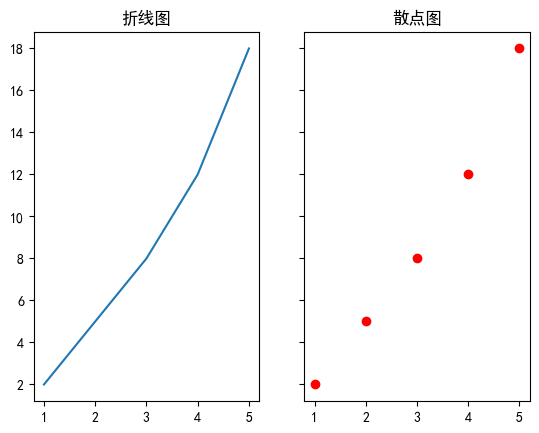

In [ ]:
# 为x轴y轴指定数据
x = [1, 2, 3, 4, 5]
y = [2, 5, 8, 12, 18]
# 绘制1行两列的子图，sharey=True设置共用y轴
fig, ax = plt.subplots(nrows=1, ncols=2, sharey=True)
# 绘制第一个图（折线图）
ax1 = ax[0]
ax1.plot(x, y)
ax1.set_title("折线图")
# 绘制第二个图（散点图）
ax2 = ax[1]
ax2.scatter(x, y, color="red")
ax2.set_title("散点图")
plt.show()  # 显示图表

#### 4. 绘制函数图像

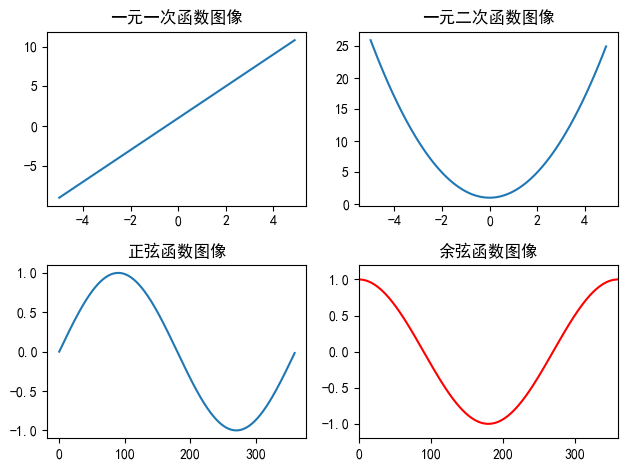

In [ ]:
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块
import numpy as np  # 导入numpy模块

plt.rcParams["font.sans-serif"] = ["SimHei"]  # 解决中文乱码
plt.rcParams["axes.unicode_minus"] = False  # 解决正常显示负号

# ----- 一元一次函数图像绘制 -----
# 创建x轴数据
x = np.arange(-5, 5, 0.1)
# 通过一元一次函数计算y轴数据
y = 2 * x + 1
figure, axes = plt.subplots(2, 2)  # 2行2列的子图
axes[0, 0].plot(x, y)  # 在第一个子图中绘制图像
axes[0, 0].set_title("一元一次函数图像")  # 设置子图标题

# ----- 一元二次函数图像绘制 -----
x = np.arange(-5, 5, 0.1)  # 创建x轴数据
# 通过一元二次函数计算y轴数据
y = x**2 + 1
axes[0, 1].plot(x, y)  # 在第二个子图中绘制图像
axes[0, 1].set_title("一元二次函数图像")  # 设置子图标题

# ----- 正弦弦函数图像绘制 -----
x = np.arange(0, 360)  # x轴数据（0~360的数组，不包含360）
# 通过sin()函数计算y轴
y = np.sin(x * np.pi / 180)
axes[1, 0].plot(x, y)  # 绘制图像
axes[1, 0].set_title("正弦函数图像")  # 设置标题

# ----- 余弦函数图像绘制 -----
x = np.arange(0, 360)  # 生成0~360不包含360的一维数组
y = np.cos(x * np.pi / 180)  # 数组中角度的余弦值
axes[1, 1].plot(x, y, color="red")  # 绘制图像
axes[1, 1].set_xlim(0, 360)                 # x轴数值显示范围
axes[1, 1].set_ylim(-1.2, 1.2)              # y轴数值显示范围
axes[1, 1].set_title("余弦函数图像")     # 图像标题

plt.tight_layout()  # 自动调整子图参数
plt.show()          # 显示图像

#### 5. 绘制形状与路径
- `import matplotlib.patches as patches` 导入模块，利用模块中的函数绘制几何图形，再使用 `add_patch()` 方法将绘制完成的几何图形添加到图中
- `matplotlib.path.Path(vertices, codes=None, _interpolation_steps=1, closed=False, readonly=False)` 创建路径对象
    - `vertices` 浮点型数组，表示路径中所经过的点的坐标列表
    - `codes` 每个点对应的操作指令数组，指点与点之间的连接方式
        - `Path.MOVETO` 移动到指定点，一般指起始点
        - `Path.LINETO` 从当前位置绘制线段到点
        - `Path.CURVE3` 从当前位置画两次贝塞尔曲线到指定点，需要一个控制点
        - `Path.CURVE4` 从当前位置画三次贝塞尔曲线到指定点，需要两个控制点
        - `Path.CLOSEPOLY` 闭合路径，回到起始点
    - `_interpolation_steps` 插值步数，整形
    - `closed` 布尔值，是否闭合，如果为True，路径被视为封闭多边形
    - `readonly` 布尔值，设置路径是否只读不可变

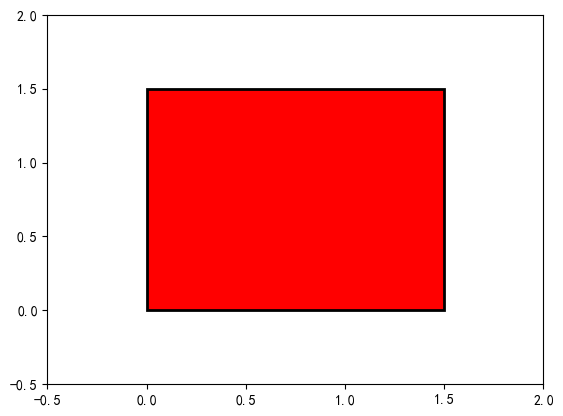

In [47]:
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块
from matplotlib.path import Path  # 导入matplotlib.path模块
import matplotlib.patches as patches  # 导入matplotlib.patches模块

verts = [
    (0.0, 0.0),  # 矩形左下角的坐标(left,bottom)
    (0.0, 1.5),  # 矩形左上角的坐标(left,top)
    (1.5, 1.5),  # 矩形右上角的坐标(right,top)
    (1.5, 0.0),  # 矩形右下角的坐标(right, bottom)
    (0.0, 0.0),
]  # 封闭到起点
codes = [Path.MOVETO, Path.LINETO, Path.LINETO, Path.LINETO, Path.CLOSEPOLY]
path = Path(verts, codes)  # 创建一个路径path对象
# 创建画图对象以及创建子图对象
fig = plt.figure()
ax = fig.add_subplot(111)
# 创建一个patch
patch = patches.PathPatch(path, facecolor="red", lw=2)
# 将创建的patch添加到axes对象中
ax.add_patch(patch)
# 设置x轴y轴的坐标轴范围
ax.axis([-0.5, 2, -0.5, 2])
# 显示图形
plt.show()

- `matplotlib.pathces.Circle(xy, radius=5, **kwargs)` 用来绘制圆形
    - `xy` 表示圆心的坐标(x, y)
    - `radius` 表示圆的半径，默认为5
    - `**kwargs` 表示其他关键字参数，例如颜色、边框等
- `matplotlib.pathces.Rectangle(xy, width, height, angle=0.0, **kwargs)` 用来绘制矩形
    - `xy` 浮点数，表示矩形左上角的坐标(x, y)
    - `width` 浮点数，表示矩形的宽度
    - `height` 浮点数，表示矩形的高度
    - `angle` 浮点数，表示矩形的旋转角度（逆时针方向），默认为0.0
    - `**kwargs` 表示其他关键字参数，例如颜色、边框等

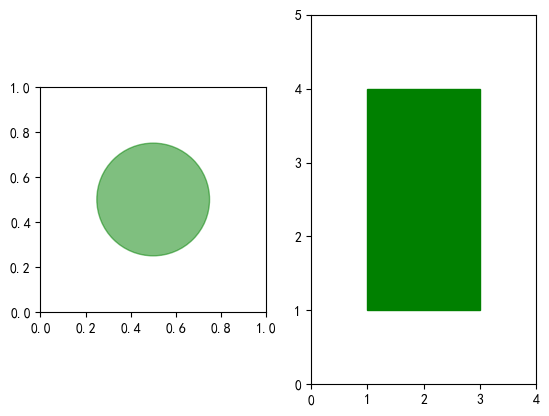

In [50]:
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块
import matplotlib.patches as patches  # 导入matplotlib.patches模块

# 使用subplots()函数创建子图，返回值是一个元组，包括一个图形对象和axes对象
fig, ax = plt.subplots(1, 2)
# 使用patches.Circle模块绘制圆
circle = patches.Circle((0.5, 0.5), 0.25, alpha=0.5, color="green")
# 使用add_patch()方法在axes对象中添加圆
ax[0].add_patch(circle)
ax[0].set_aspect("equal")  # 设置x轴和y轴比例相同以正确显示圆形

# 使用axis()函数设置x轴和y轴的坐标轴范围
ax[1].axis([0, 4, 0, 5])
# 使用patches.Rectangle模块绘制矩形
rectangle = patches.Rectangle((1, 1), 2, 3, color="green")
# 使用add_patch()方法在axes对象中添加矩形
ax[1].add_patch(rectangle)
# 显示图形
plt.show()

#### 6. 绘制 3D 图
- 3D 柱形图

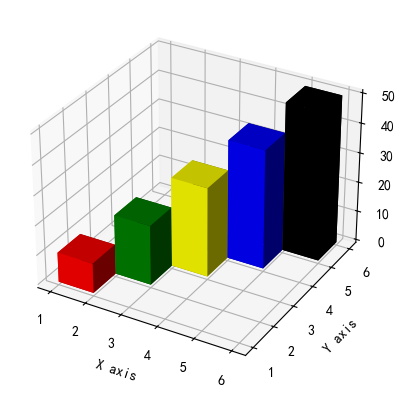

In [54]:
import numpy as np
import matplotlib.pyplot as plt

# 创建数据
x = np.array([1, 2, 3, 4, 5])
y = np.array([1, 2, 3, 4, 5])
z = np.zeros(5)
dx = np.ones(5)
dy = np.ones(5)
dz = np.array([10, 20, 30, 40, 50])

# 创建图形和轴
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# 绘制3D柱形图
ax.bar3d(x, y, z, dx, dy, dz, color=["r", "green", "yellow", "blue", "black"])

# 设置坐标轴标签
ax.set_xlabel("X axis")
ax.set_ylabel("Y axis")
ax.set_zlabel("Z axis")

# 显示图形
plt.show()

- 3D 曲面图

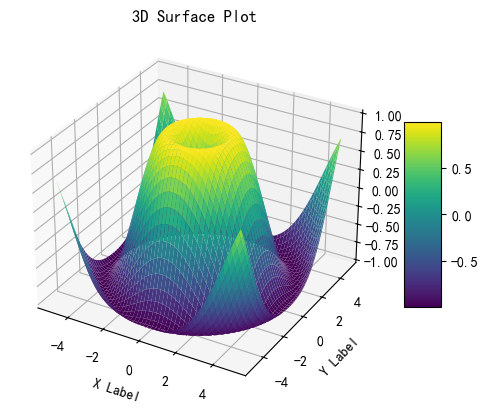

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# 创建一个新的图形
fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

# 生成X和Y数据，假设我们有一个10x10的网格
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
x, y = np.meshgrid(x, y)

# 计算Z数据，这里我们使用一个简单的函数 z = sin(sqrt(x^2 + y^2))
z = np.sin(np.sqrt(x**2 + y**2))

# 绘制3D曲面图
surf = ax.plot_surface(x, y, z, cmap="viridis")

# 添加颜色条，以显示高度信息
fig.colorbar(surf, ax=ax, shrink=0.5, aspect=5)

# 设置轴标签
ax.set_xlabel("X Label")
ax.set_ylabel("Y Label")
ax.set_zlabel("Z Label")

# 设置标题
ax.set_title("3D Surface Plot")

# 显示图形
plt.show()

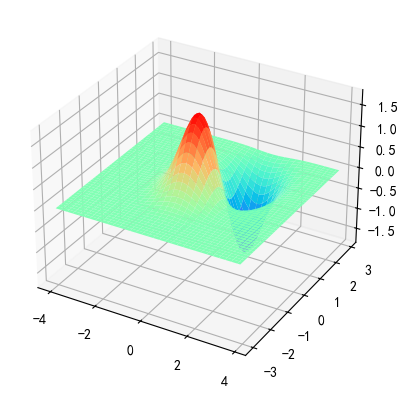

In [56]:
import matplotlib.pyplot as plt
import numpy as np

fig = plt.figure()
ax = fig.add_subplot(projection="3d")
x = np.arange(-4.0, 4.0, 0.125)
y = np.arange(-3.0, 3.0, 0.125)
X, Y = np.meshgrid(x, y)
Z1 = np.exp(-(X**2) - Y**2)
Z2 = np.exp(-((X - 1) ** 2) - (Y - 1) ** 2)
# 计算Z轴数据（高度数据）
Z = (Z1 - Z2) * 2
ax.plot_surface(X, Y, Z, cmap=plt.get_cmap("rainbow"))
plt.show()